In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import MinMaxScaler 
from keras.models import Sequential 
from keras.layers import Dense,LSTM,Dropout 

In [9]:
#2. Load Dataset
data = pd.read_csv("Google_Stock_Price.csv")


data.head()

,Price,Adj Close,Close,High,Low,Open,Volume
0,Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
1,Date,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-02 00:00:00+00:00,68.18682098,68.43399811,68.43399811,67.32450104,67.42050171,27278000
3,2020-01-03 00:00:00+00:00,67.83010101,68.0759964,68.6875,67.36599731,67.40000153,23408000
4,2020-01-06 00:00:00+00:00,69.63805389,69.89050293,69.91600037,67.55000305,67.58149719,46768000


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1260 non-null   object
 1   Adj Close  1259 non-null   object
 2   Close      1259 non-null   object
 3   High       1259 non-null   object
 4   Low        1259 non-null   object
 5   Open       1259 non-null   object
 6   Volume     1259 non-null   object
dtypes: object(7)
memory usage: 69.0+ KB


In [13]:


data["Close"]=pd.to_numeric(data.Close,errors='coerce') 
data = data.dropna() 
trainData = data.iloc[:,4:5].values 
data.info() 


<class 'pandas.core.frame.DataFrame'>
Index: 1258 entries, 2 to 1259
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Price      1258 non-null   object 
 1   Adj Close  1258 non-null   object 
 2   Close      1258 non-null   float64
 3   High       1258 non-null   object 
 4   Low        1258 non-null   object 
 5   Open       1258 non-null   object 
 6   Volume     1258 non-null   object 
dtypes: float64(1), object(6)
memory usage: 78.6+ KB


In [15]:
sc = MinMaxScaler(feature_range=(0,1)) 
trainData = sc.fit_transform(trainData) 
trainData.shape 

(1258, 1)

In [19]:
X_train = []
y_train = []

for i in range(60, 1149):   # 60 = timestep

    X_train.append(trainData[i-60:i, 0])
    y_train.append(trainData[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

X_train = np.reshape(
    X_train,
    (X_train.shape[0], X_train.shape[1], 1)
)

X_train.shape

(1089, 60, 1)

In [22]:
model = Sequential() 
model.add(LSTM(units=100, return_sequences = True, input_shape 
=(X_train.shape[1],1))) 
model.add(Dropout(0.2)) 
model.add(LSTM(units=100, return_sequences = True)) 
model.add(Dropout(0.2)) 
model.add(LSTM(units=100, return_sequences = True)) 
model.add(Dropout(0.2)) 
model.add(LSTM(units=100, return_sequences = False)) 
model.add(Dropout(0.2)) 
model.add(Dense(units =1)) 
model.compile(optimizer='adam',loss="mean_squared_error") 

C:\Users\Patil\anaconda3\anac\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [24]:
hist = model.fit(X_train, y_train, epochs = 20, batch_size = 32, verbose=2)

Epoch 1/20
35/35 - 17s - 494ms/step - loss: 0.0343
Epoch 2/20
35/35 - 5s - 144ms/step - loss: 0.0046
Epoch 3/20
35/35 - 15s - 415ms/step - loss: 0.0033
Epoch 4/20
35/35 - 8s - 226ms/step - loss: 0.0038
Epoch 5/20
35/35 - 5s - 142ms/step - loss: 0.0038
Epoch 6/20
35/35 - 4s - 127ms/step - loss: 0.0032
Epoch 7/20
35/35 - 5s - 131ms/step - loss: 0.0038
Epoch 8/20
35/35 - 8s - 239ms/step - loss: 0.0030
Epoch 9/20
35/35 - 8s - 215ms/step - loss: 0.0026
Epoch 10/20
35/35 - 5s - 130ms/step - loss: 0.0030
Epoch 11/20
35/35 - 5s - 130ms/step - loss: 0.0026
Epoch 12/20
35/35 - 5s - 153ms/step - loss: 0.0026
Epoch 13/20
35/35 - 6s - 182ms/step - loss: 0.0025
Epoch 14/20
35/35 - 10s - 283ms/step - loss: 0.0024
Epoch 15/20
35/35 - 4s - 126ms/step - loss: 0.0028
Epoch 16/20
35/35 - 5s - 135ms/step - loss: 0.0024
Epoch 17/20
35/35 - 5s - 146ms/step - loss: 0.0030
Epoch 18/20
35/35 - 7s - 186ms/step - loss: 0.0024
Epoch 19/20
35/35 - 9s - 244ms/step - loss: 0.0034
Epoch 20/20
35/35 - 4s - 128ms/step -

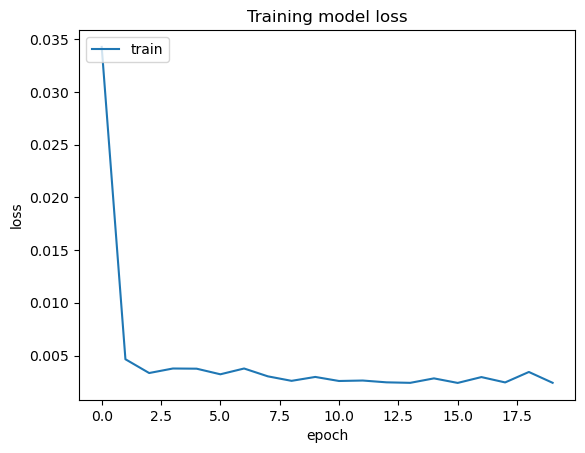

In [26]:
plt.plot(hist.history['loss']) 
plt.title('Training model loss') 
plt.ylabel('loss') 
plt.xlabel('epoch') 
plt.legend(['train'], loc='upper left') 
plt.show() 

In [28]:
data["Close"] = pd.to_numeric(data["Close"], errors='coerce') 

In [30]:
data = data.dropna() 
# Select Close column 
data = data.iloc[:, 4:5] 
# Create y_test 
y_test = data.iloc[60:, 0:].values 
# Prepare input for model 
inputClosing = data.iloc[:, 0:].values 
inputClosing_scaled = sc.transform(inputClosing)

In [32]:
# Create X_test 
X_test = [] 
timestep = 60 
length = len(data) 
 
for i in range(timestep, length): 
    X_test.append(inputClosing_scaled[i - timestep:i, 0]) 
 
X_test = np.array(X_test) 

In [34]:
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1)) 
 
print(X_test.shape)

(1198, 60, 1)


In [36]:
y_pred = model.predict(X_test) 
y_pred 

38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step


array([[0.0517645 ],
       [0.04899184],
       [0.04735731],
       ...,
       [0.965425  ],
       [0.9721544 ],
       [0.97760504]], dtype=float32)

In [40]:
predicted_price = sc.inverse_transform(y_pred) 


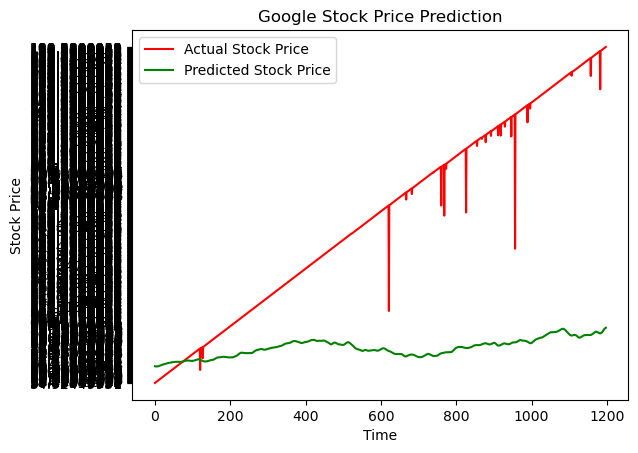

In [44]:
y_test = np.array(y_test).reshape(-1)
predicted_price = np.array(predicted_price).reshape(-1)

plt.plot(y_test, color='red', label='Actual Stock Price')
plt.plot(predicted_price, color='green', label='Predicted Stock Price')

plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')

plt.legend()
plt.show()